## Assignment C - s3536653


The goal of this assignment was to inspect the provided data, clean and structure it, and prepare it for analysis. A second objective was to investigate whether there is a relationship between BMI and the expression of certain genes.

# Preprocessing

After close inspection of the data, several inconsistencies were found:

1. The columns were not ordered consistently across the CSV files.
2. The dataset contained missing values.
3. Some entries contained invalid values, such as negative height measurements.
4. The ID format used for the US and PL differed from the ID format used for NL and UK.
5. The genes dataset contained all individuals measured, but not all individuals for whom we had data.
6. UK individuals were measured using the imperial system instead of the metric system.
7. The output of the country-specific datasets was not standardized.

For all of these inconsistencies, a solution was implemented. The numbering corresponds to the solutions described below.


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

In [107]:
# Problem 1
# First, order the CSV files consistently by 'id', 'height', 'weight', 'sex', and 'smokes'.
order = ['id', 'height', 'weight', 'sex', 'smokes']
nl = pd.read_csv('../data/NL.csv')
pl = pd.read_csv('../data/PL.csv')
uk = pd.read_csv('../data/UK.csv')
us = pd.read_csv('../data/US.csv')
genes = pd.read_csv('../data/genes.csv')

nl = nl[order]
pl = pl.rename(columns={'heigth': 'height'})
# Misspelled column name in the PL file.
pl = pl[order]
uk = uk[order]
us = us[order]

# Now that the order is the same, merge the DataFrames.
total_v1 = pd.concat([nl, pl, uk, us], ignore_index=True)
print(total_v1['id'].nunique())
print(total_v1.shape[0])
# After merging, it seems that the length of the joined DataFrame is greater than the length of the genes DataFrame.
# I suspect this is because of missing values and implausible values.


3816
4015


In [108]:
# Problem 7
# 'sex'
total_v1['sex'].unique()
total_v1['sex'] = total_v1['sex'].replace({'male': 'MALE', 'Male': 'MALE', 'female': 'FEMALE', 'Woman': 'FEMALE', 'Female': 'FEMALE'})
total_v1['sex'].isna().sum()    # 34 missing values
total_v1['sex'] = total_v1['sex'].astype('category')
total_v1.loc[total_v1['sex'].isna(), 'id'].tolist()     # All missing genders are from Poland. It is unclear why, but the amount is small enough to take into account in the analysis.


['S000b',
 'S0052',
 'S0070',
 'S00a6',
 'S00d4',
 'S0101',
 'S0130',
 'S015a',
 'S0176',
 'S0192',
 'S019a',
 'S01ab',
 'S01b0',
 'S01d3',
 'S01ec',
 'S0228',
 'S0240',
 'S02bd',
 'S02c3',
 'S02e0',
 'S02f7',
 'S02fc',
 'S0303',
 'S0317',
 'S031f',
 'S0362',
 'S0374',
 'S037a',
 'S0437',
 'S0462',
 'S0473',
 'S047c',
 'S04fc',
 'S053a']

In [109]:
# Problem 7
# 'smokes'
total_v1['smokes'].unique()
total_v1['smokes'] = total_v1['smokes'].replace({'yes': True, 'no': False})
total_v1['smokes'].isna().sum()    # 104 missing
total_v1.loc[total_v1['smokes'].isna(), 'id'].tolist()      # Again, all missing values are from the Polish dataset; interpret this with caution.


['S002e',
 'S0030',
 'S003c',
 'S0078',
 'S008a',
 'S0098',
 'S00a6',
 'S00ab',
 'S00b1',
 'S00d0',
 'S00d4',
 'S00d5',
 'S00ef',
 'S00fe',
 'S0115',
 'S011e',
 'S011f',
 'S012b',
 'S0134',
 'S013f',
 'S0148',
 'S014c',
 'S0150',
 'S015b',
 'S015d',
 'S015e',
 'S016b',
 'S017f',
 'S018f',
 'S0194',
 'S019a',
 'S01bd',
 'S01c0',
 'S01da',
 'S01ff',
 'S0208',
 'S020b',
 'S020d',
 'S020e',
 'S021c',
 'S0223',
 'S0226',
 'S023d',
 'S0278',
 'S0289',
 'S028d',
 'S02a8',
 'S02ae',
 'S02b4',
 'S02b9',
 'S02ba',
 'S02c4',
 'S02cd',
 'S02d4',
 'S02f4',
 'S0329',
 'S032a',
 'S033d',
 'S0346',
 'S034b',
 'S0354',
 'S0356',
 'S035c',
 'S0367',
 'S036d',
 'S0378',
 'S038a',
 'S0399',
 'S03aa',
 'S03ae',
 'S03d2',
 'S03de',
 'S03e3',
 'S03e8',
 'S03fa',
 'S03fe',
 'S0406',
 'S040b',
 'S041b',
 'S0425',
 'S042c',
 'S042f',
 'S0433',
 'S0434',
 'S0436',
 'S043a',
 'S0445',
 'S0462',
 'S046a',
 'S046b',
 'S046c',
 'S0471',
 'S047a',
 'S0484',
 'S04ae',
 'S04bd',
 'S04c7',
 'S04d6',
 'S04dc',
 'S04ee',


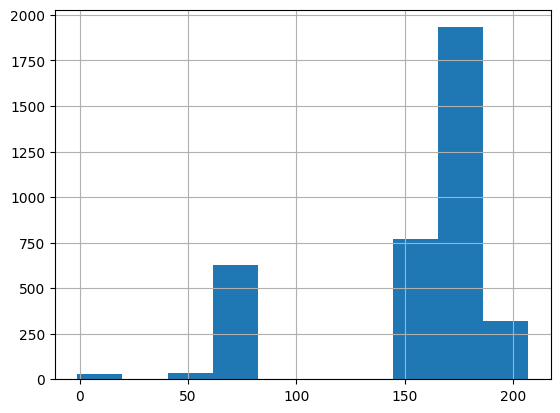

In [110]:
# Problem 6, 7
# 'height'
total_v1['height'].hist()
# The histogram of the height variable showed inconsistent values in the UK dataset. It is assumed that the values are in inches instead of centimeters.
conversion = 2.54
mask = total_v1['id'].astype(str).str.startswith('UK', na=False)
total_v1.loc[mask, 'height'] *= conversion


In [111]:
# Problem 3
# 'height'
total_v1['height'].describe()   # The minimum is negative.
total_v1 = total_v1[total_v1['height'] >= 0]    # No negative values remain.


In [112]:
# Problem 6, 7
# 'weight'
total_v1['weight'].describe()  # The maximum value is implausible, while the minimum value can be possible.
total_v1 = total_v1[total_v1['weight'] != total_v1['weight'].max()]    # The maximum weight is removed.
total_v1['weight'].isna().sum()     # 42 missing values
total_v1.loc[total_v1['weight'].isna(), 'id'].tolist()  # All missing values are from Poland.


['S001d',
 'S0045',
 'S0051',
 'S0060',
 'S0069',
 'S0097',
 'S00bf',
 'S00fc',
 'S0150',
 'S015e',
 'S016d',
 'S01be',
 'S020f',
 'S0217',
 'S021d',
 'S023b',
 'S024d',
 'S024e',
 'S026b',
 'S0287',
 'S02da',
 'S034b',
 'S038e',
 'S0397',
 'S03b6',
 'S03f8',
 'S03fe',
 'S0414',
 'S0419',
 'S0433',
 'S0437',
 'S0448',
 'S0458',
 'S046b',
 'S048e',
 'S04bd',
 'S04c2',
 'S04cc',
 'S04d0',
 'S050a',
 'S0519',
 'S0530']

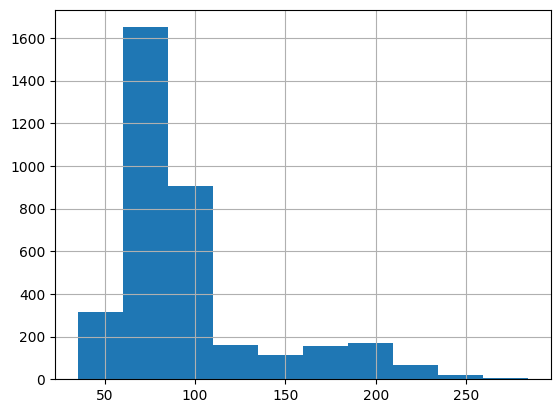

In [113]:
# Problem 6, 7
# 'weight' -- UK values were measured in pounds
total_v1['weight'].hist()
conversion = 0.45359237
mask = total_v1['id'].astype(str).str.startswith('UK', na=False)
total_v1.loc[mask, 'weight'] *= conversion


In [114]:
# Problem 2
# Removal of NA values: they are few, but interpretation of the statistics should be cautious since all missing data is from Poland.
total_v1 = total_v1.dropna()


Now that the individual variables have been cleaned, it is time to combine `total_v1` with the genes DataFrame. However, the two DataFrames do not have the same length. They were matched based on shared IDs.


In [ ]:
df = total_v1.merge(genes, on='id', how='inner')
# There was not enough data for all individuals; only 3277 individuals had both gene data and the secondary variables such as height and weight.
not_in_df = total_v1[~total_v1['id'].isin(df['id'])].copy()
ids = not_in_df['id'].astype(str).str.upper()
not_in_df.loc[:, 'country'] = np.select(
    [
        ids.str.startswith('NL'),
        ids.str.startswith('UK'),
        ids.str.startswith('S1'),
        ids.str.startswith('S0')
    ],
    [
        'NL',
        'UK',
        'US',
        'PL'
    ],
    default='Unknown'
)

summary = pd.DataFrame({
    'country': not_in_df['country'].value_counts(),
    'sex': not_in_df['sex'].value_counts(),
    'smokes': not_in_df['smokes'].value_counts(),
})

summary


,country,sex,smokes
FEMALE,NaN,4.0,NaN
MALE,NaN,155.0,NaN
US,159.0,NaN,NaN
False,NaN,NaN,144.0
True,NaN,NaN,15.0


Before continuing with the correct data, I wanted to inspect the data that was not matched by the IDs. It appeared that predominantly US individuals were not matched, mostly males and non-smokers. In addition, the Polish individuals who had missing values were also excluded. This should be taken into account when interpreting the statistical results.


## Data Analysis

In [116]:
# First add BMI
df['BMI'] = df['weight'] / ((df['height'] / 100)) ** 2

# Second, add country
ids = df['id'].astype(str).str.upper()
df['country'] = np.select(
    [
        ids.str.startswith('NL'),
        ids.str.startswith('UK'),
        ids.str.startswith('S1'),
        ids.str.startswith('S0')
    ],
    [
        'NL',
        'UK',
        'US',
        'PL'
    ],
    default='Unknown'
)


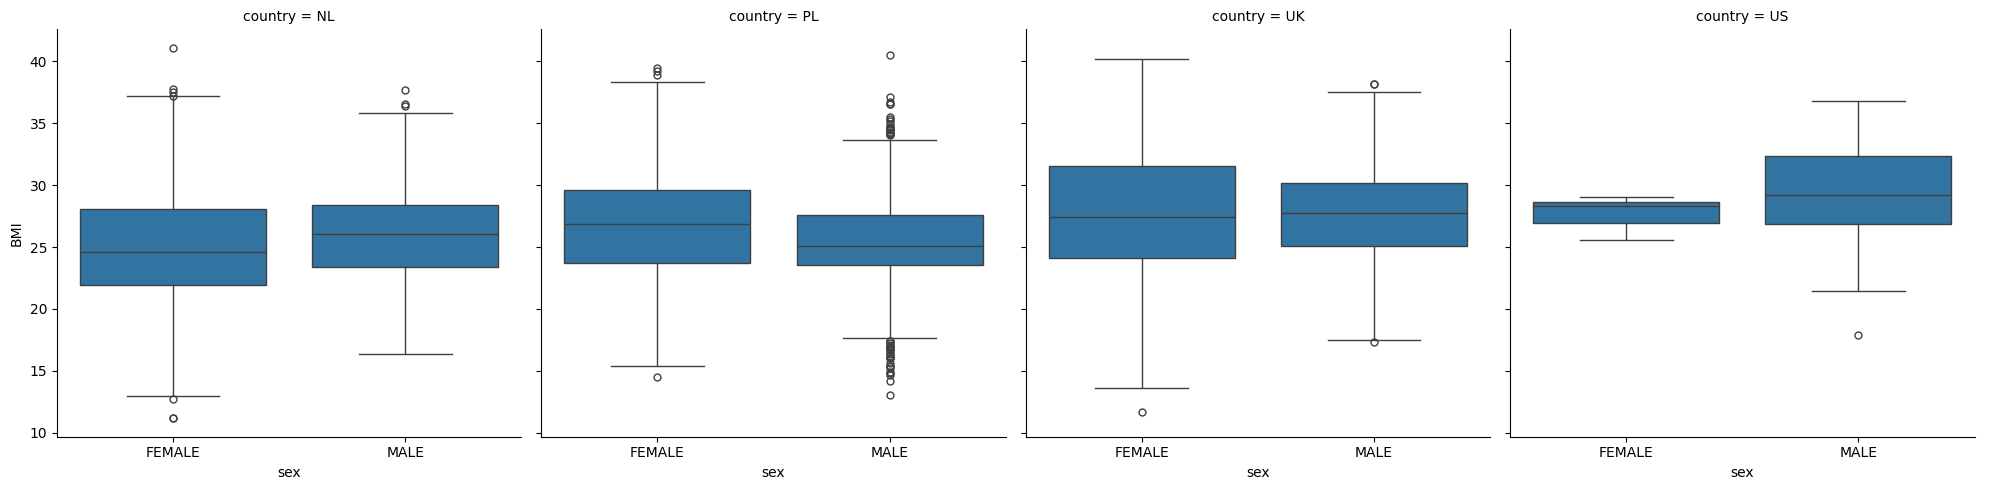

In [117]:
# BMI per sex per country
sns.catplot(
    data=df,
    x='sex',
    y='BMI',
    col='country',
    kind='box'
)


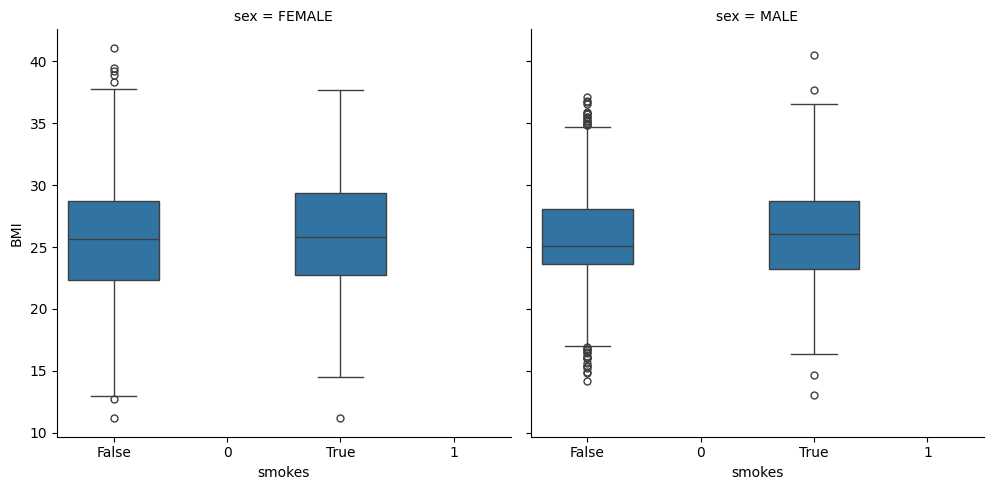

In [118]:
# BMI per smoking status per sex
sns.catplot(
    data=df,
    x='smokes',
    y='BMI',
    col='sex',
    kind='box'
)


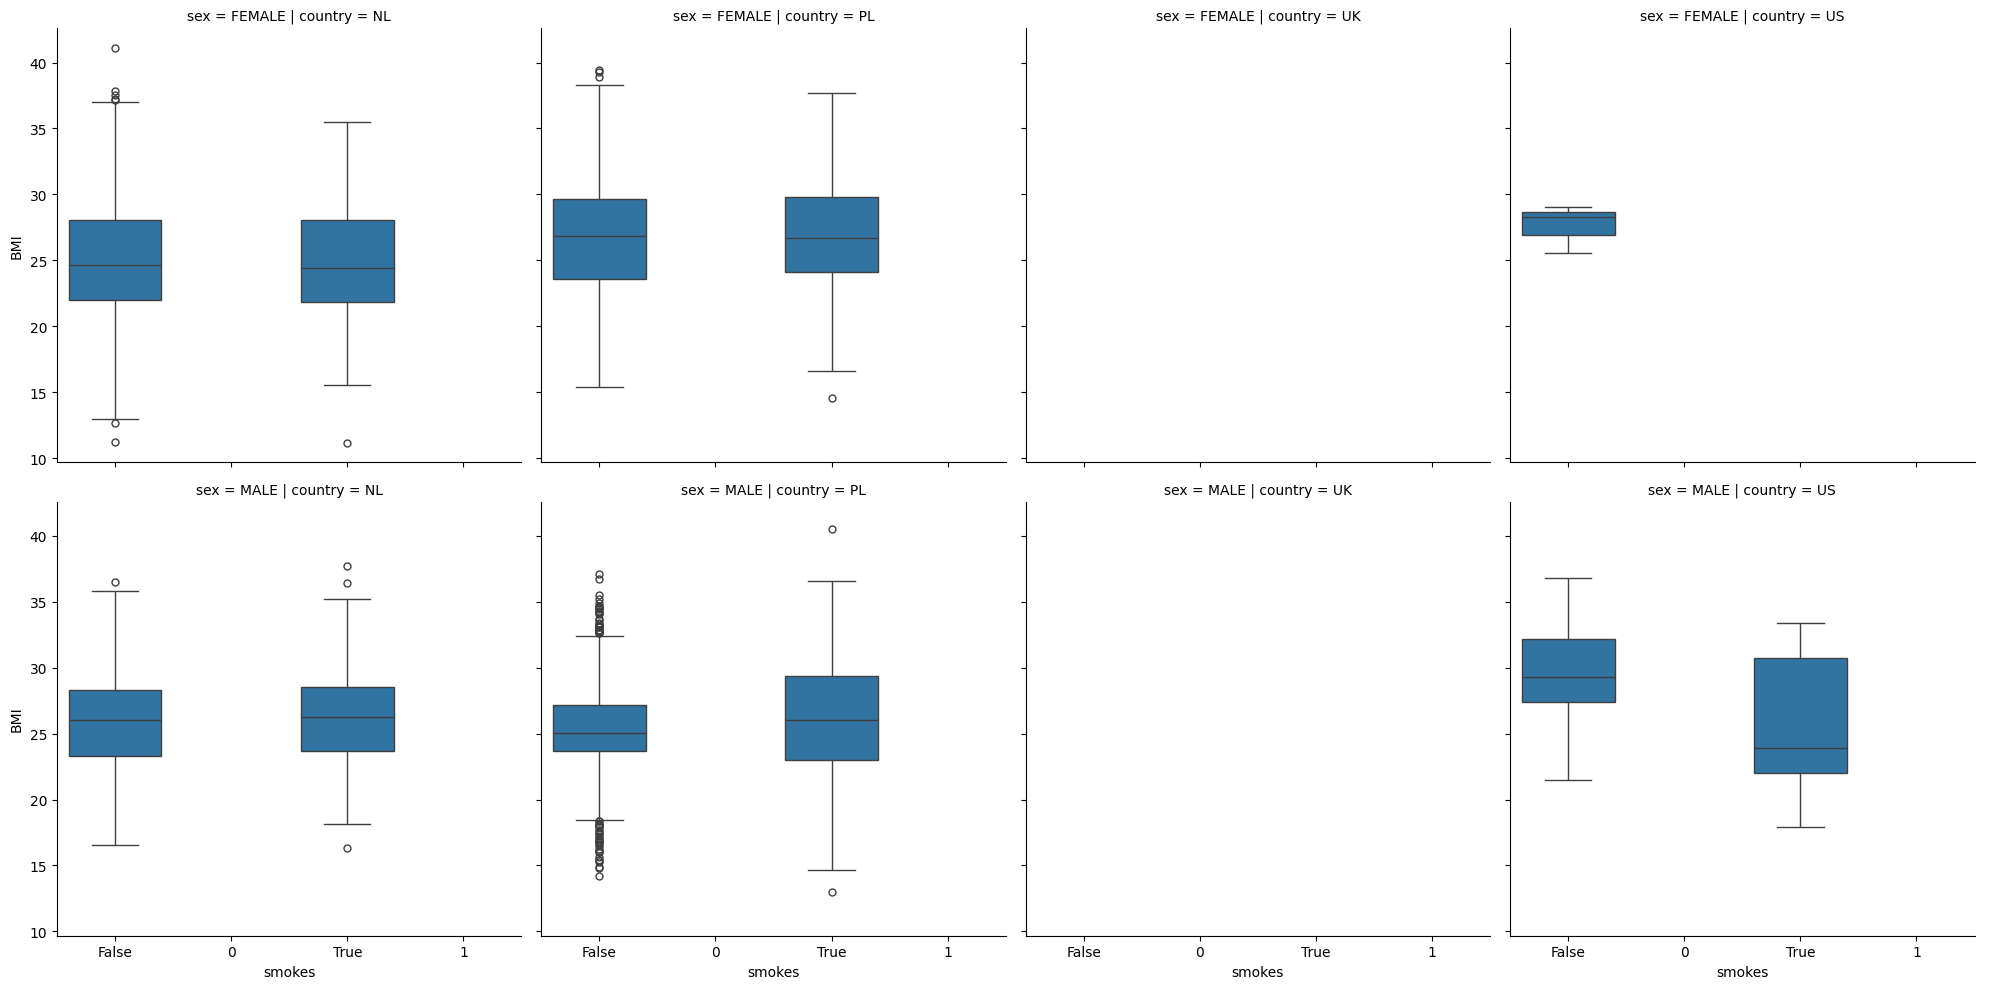

In [119]:
# BMI per country, sex, and smoking status
sns.catplot(
    data=df,
    x='smokes',
    y='BMI',
    col='country',
    row='sex',
    kind='box'
)


In [ ]:
# Gene B and Gene C show approximately normal distributions, so Pearson correlation was used to assess their relationship with BMI. Gene A was skewed, so Spearman correlation was considered more appropriate.
# First, I conduct simple univariate regressions.

rho_a, p_a = spearmanr(df['BMI'], df['geneA'], nan_policy='omit')
r_b, p_b = pearsonr(df['BMI'], df['geneB'])
r_c, p_c = pearsonr(df['BMI'], df['geneC'])

print(f'geneA Spearman: rho = {rho_a:.3f}, p = {p_a:.3g}')
print(f'geneB Pearson:  r = {r_b:.3f}, p = {p_b:.3g}')
print(f'geneC Pearson:  r = {r_c:.3f}, p = {p_c:.3g}')

# Univariate analyses showed that BMI was significantly associated with geneA and geneB expression, while no significant association was found for geneC.

model_1 = smf.ols('BMI ~ geneA + geneB + geneC', data=df).fit()
# geneC was not relevant in the simpler additive model.
model_2 = smf.ols('BMI ~ geneA + geneB', data=df).fit()
print(model_2.summary())


geneA Spearman: SignificanceResult(statistic=np.float64(0.8885835104325672), pvalue=np.float64(0.0))
geneB Pearson: PearsonRResult(statistic=np.float64(0.8142820021700024), pvalue=np.float64(0.0))
geneC Pearson: PearsonRResult(statistic=np.float64(0.019761549221075193), pvalue=np.float64(0.257793813210952))
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     4394.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:34:36   Log-Likelihood:                -7341.7
No. Observations:                3281   AIC:                         1.469e+04
Df Residuals:                    3278   BIC:                         1.471e+04
Df Model:                           2                      

Univariate analyses showed that BMI was strongly associated with geneA and geneB expression, whereas geneC did not show a significant association with BMI. A multiple linear regression model including geneA and geneB explained 72.8% of the variance in BMI, indicating that these genes are strongly related to BMI in this dataset.


In [121]:
# Export df to CSV
df.to_csv('../out/final_df.csv', index=False)
